In [1]:
import sys

import pandas as pd
sys.path.append("../src")
from utils import code_fix

In [2]:
gdp = pd.read_csv("../data/gdp_per_capita/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv", skiprows=4, encoding="utf-8-sig")
year_cols = [c for c in gdp.columns if c.isdigit()]

ranks = gdp[year_cols].rank(ascending=False, method="min", na_option="keep")
n = gdp[year_cols].count()
gdp[year_cols] = 1 - (ranks - 1) / (n - 1)

gdp_long = gdp[["Country Name", "Country Code", *year_cols]].melt(
    id_vars=["Country Name", "Country Code"],
    var_name="year",
    value_name="gdp_usd"
)

gdp_long["year"] = pd.to_numeric(gdp_long["year"], errors="coerce").astype("Int64")

olympic_df = pd.read_csv("../data/olympic_medals.csv")
olympic_df = olympic_df[olympic_df["year"] >= 1960].copy()
olympic_df["Country Code"] = olympic_df["country_code"].str.upper().str.strip().replace(code_fix)

merged = olympic_df.merge(
    gdp_long[["Country Code", "year", "gdp_usd"]],
    on=["Country Code", "year"],
    how="left"
)

In [3]:
merged[merged["year"]==2024].groupby("country").agg({"gdp_usd": "mean", "medal": "count"}).reset_index().sort_values("gdp_usd", ascending=False)

,country,gdp_usd,medal
43,Ireland,0.987448,7
82,Switzerland,0.983264,8
76,Singapore,0.979079,1
63,Norway,0.974895,8
89,United States,0.966527,126
...,...,...,...
0,AIN,NaN,5
17,Chinese Taipei,NaN,7
21,Cuba,NaN,9
51,Korea DPR,NaN,6


In [4]:
# aggregate mean GDP by year and sport
gdp_by_sport_year = merged.groupby(["sport","year"]).agg(
    mean_gdp=pd.NamedAgg(column="gdp_usd", aggfunc="mean")
).reset_index()

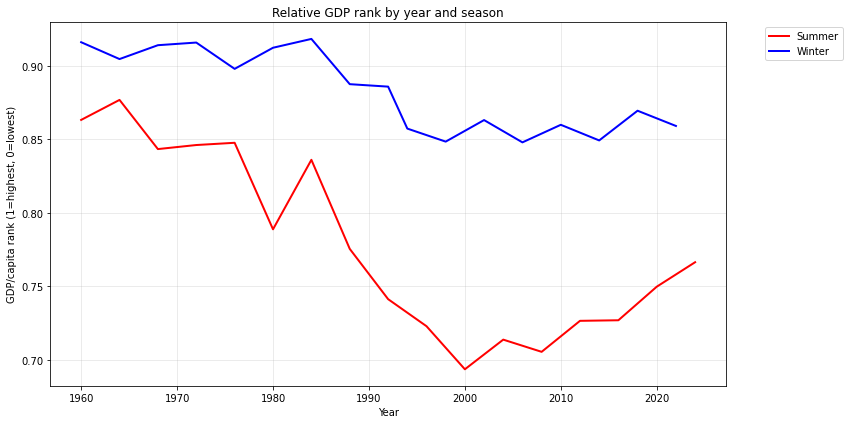

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
gdp_by_year_summer = merged[merged["season"] == "Summer"].groupby("year").agg({"gdp_usd": "mean"}).reset_index()
plt.plot(gdp_by_year_summer["year"], gdp_by_year_summer["gdp_usd"], label="Summer", color="red", linewidth=2)
gdp_by_year_winter = merged[merged["season"] == "Winter"].groupby("year").agg({"gdp_usd": "mean"}).reset_index()
plt.plot(gdp_by_year_winter["year"], gdp_by_year_winter["gdp_usd"], label="Winter", color="blue", linewidth=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.xlabel("Year")
plt.ylabel("GDP/capita rank (1=highest, 0=lowest)")
plt.title("Relative GDP rank by year and season")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("../figures/gdp_rank_by_year.png", dpi=600)
plt.show()

In [6]:
gdp_by_sport = gdp_by_sport_year.groupby("sport", as_index=False)["mean_gdp"].mean()
gdp_by_sport["mean_gdp"] = (gdp_by_sport["mean_gdp"] * 100).map(lambda x: f"{x:.1f}%")
gdp_by_sport = gdp_by_sport.sort_values("mean_gdp", ascending=False)
print(gdp_by_sport.head(10).to_markdown(index=False))
print(gdp_by_sport.tail(10).to_markdown(index=False))

| sport               | mean_gdp   |
|:--------------------|:-----------|
| Alpine Skiing       | 91.5%      |
| Curling             | 91.4%      |
| Nordic Combined     | 91.0%      |
| Equestrian Dressage | 91.0%      |
| Equestrian          | 91.0%      |
| Softball            | 90.8%      |
| Ice Hockey          | 90.5%      |
| Bobsleigh           | 90.4%      |
| Snowboard           | 90.3%      |
| Speed skating       | 90.2%      |
| sport               | mean_gdp   |
|:--------------------|:-----------|
| Boxing              | 67.2%      |
| Karate              | 66.6%      |
| Taekwondo           | 66.2%      |
| Gymnastics Rhythmic | 65.1%      |
| Weightlifting       | 65.1%      |
| Trampoline          | 64.7%      |
| Wrestling           | 62.4%      |
| Table Tennis        | 57.5%      |
| Badminton           | 56.5%      |
| Artistic swimming   | 54.0%      |


In [124]:
# calculate GDP rank per country normalized every year. Have the number of medals per country and year, country name, include both seasons not just first
gdp_by_country_year_summer = merged[merged["season"] == "Summer"].groupby(["Country Code", "year"]).agg(
    gdp_rank=pd.NamedAgg(column="gdp_usd", aggfunc="mean"),
    medal_count=pd.NamedAgg(column="medal", aggfunc="count"),
    country_name=pd.NamedAgg(column="country", aggfunc="first"),
    season =pd.NamedAgg(column="season", aggfunc="first")
).reset_index()

# calculate GDP rank per country normalized every year. Have the number of medals per country and year, country name, include both seasons not just first
gdp_by_country_year_winter = merged[merged["season"] == "Winter"].groupby(["Country Code", "year"]).agg(
    gdp_rank=pd.NamedAgg(column="gdp_usd", aggfunc="mean"),
    medal_count=pd.NamedAgg(column="medal", aggfunc="count"),
    country_name=pd.NamedAgg(column="country", aggfunc="first"),
    season =pd.NamedAgg(column="season", aggfunc="first")
).reset_index()

In [125]:
display(gdp_by_country_year_summer.head(5))
gdp_by_country_year_summer[(gdp_by_country_year_summer['Country Code']=="EGY") & (gdp_by_country_year_summer['year']==2024)]

,Country Code,year,gdp_rank,medal_count,country_name,season
0,AFG,2008,0.015504,1,Afghanistan,Summer
1,AFG,2012,0.038610,1,Afghanistan,Summer
2,AIN,2024,NaN,5,AIN,Summer
3,ALB,2024,0.581590,2,Albania,Summer
4,ARE,2004,0.894531,1,United Arab Emirates,Summer


,Country Code,year,gdp_rank,medal_count,country_name,season
316,EGY,2024,0.297071,3,Egypt,Summer


In [126]:
display(gdp_by_country_year_winter.head(5))
gdp_by_country_year_winter[(gdp_by_country_year_winter['Country Code']=="CHE") & (gdp_by_country_year_winter['year']==2022)]

,Country Code,year,gdp_rank,medal_count,country_name,season
0,AUS,1994,0.880658,1,Australia,Winter
1,AUS,1998,0.875502,1,Australia,Winter
2,AUS,2002,0.843750,2,Australia,Winter
3,AUS,2006,0.887160,2,Australia,Winter
4,AUS,2010,0.946154,3,Australia,Winter


,Country Code,year,gdp_rank,medal_count,country_name,season
72,CHE,2022,0.976562,15,Switzerland,Winter


In [127]:
gdp_by_country_year_winter.isna().sum()

Country Code     0
year             0
gdp_rank        22
medal_count      0
country_name     0
season           0
dtype: int64

In [128]:
# drop rows with missing GDP values
gdp_by_country_year_winter = gdp_by_country_year_winter.dropna(subset=["gdp_rank", "medal_count"]).copy()
gdp_by_country_year_summer = gdp_by_country_year_summer.dropna(subset=["gdp_rank", "medal_count"]).copy()

In [129]:
gdp_by_country_year_summer["gdp_rank_clipped"] = gdp_by_country_year_summer["gdp_rank"].clip(lower=0.05)
gdp_by_country_year_summer["medal_rank"] = gdp_by_country_year_summer.groupby("year")["medal_count"].rank(ascending=False, method="min")
summer_country_counts = gdp_by_country_year_summer.groupby("year")["Country Code"].transform("count")
# normalise medal rank
gdp_by_country_year_summer["medal_rank"] = 1 - (gdp_by_country_year_summer["medal_rank"] - 1) / (summer_country_counts - 1)
gdp_by_country_year_summer


,Country Code,year,gdp_rank,medal_count,country_name,season,gdp_rank_clipped,medal_rank
0,AFG,2008,0.015504,1,Afghanistan,Summer,0.050000,0.202381
1,AFG,2012,0.038610,1,Afghanistan,Summer,0.050000,0.228916
3,ALB,2024,0.581590,2,Albania,Summer,0.581590,0.279070
4,ARE,2004,0.894531,1,United Arab Emirates,Summer,0.894531,0.126761
5,ARE,2016,0.895349,1,United Arab Emirates,Summer,0.895349,0.231707
...,...,...,...,...,...,...,...,...
1085,ZMB,1996,0.150407,1,Zambia,Summer,0.150407,0.250000
1086,ZMB,2024,0.100418,1,Zambia,Summer,0.100418,0.151163
1087,ZWE,1980,0.434783,1,Zimbabwe,Summer,0.434783,0.178571
1088,ZWE,2004,0.128906,3,Zimbabwe,Summer,0.128906,0.323944


In [131]:
gdp_by_country_year_summer["efficiency"] = gdp_by_country_year_summer["medal_rank"] / gdp_by_country_year_summer["gdp_rank_clipped"]
gdp_by_country_year_summer

,Country Code,year,gdp_rank,medal_count,country_name,season,gdp_rank_clipped,medal_rank,efficiency
0,AFG,2008,0.015504,1,Afghanistan,Summer,0.050000,0.202381,4.047619
1,AFG,2012,0.038610,1,Afghanistan,Summer,0.050000,0.228916,4.578313
3,ALB,2024,0.581590,2,Albania,Summer,0.581590,0.279070,0.479839
4,ARE,2004,0.894531,1,United Arab Emirates,Summer,0.894531,0.126761,0.141706
5,ARE,2016,0.895349,1,United Arab Emirates,Summer,0.895349,0.231707,0.258790
...,...,...,...,...,...,...,...,...,...
1085,ZMB,1996,0.150407,1,Zambia,Summer,0.150407,0.250000,1.662162
1086,ZMB,2024,0.100418,1,Zambia,Summer,0.100418,0.151163,1.505329
1087,ZWE,1980,0.434783,1,Zimbabwe,Summer,0.434783,0.178571,0.410714
1088,ZWE,2004,0.128906,3,Zimbabwe,Summer,0.128906,0.323944,2.513017


In [132]:
window_size = 10 
latest_year = 2024

summer_end_years = sorted(y for y in gdp_by_country_year_summer["year"].unique() if y <= latest_year)
summer_windowed_efficiency = pd.concat([
    gdp_by_country_year_summer[
        (gdp_by_country_year_summer["year"] >= max(summer_end_years[0], end_year - window_size + 1))
        & (gdp_by_country_year_summer["year"] <= end_year)
    ]
    .groupby(["Country Code", "country_name", "season"], as_index=False)
    .agg(
        avg_medal_rank=("medal_rank", "mean"),
        avg_gdp_rank=("gdp_rank_clipped", "mean"),
        total_medals=("medal_count", "sum"),
        editions=("year", "nunique"),
    )
    .assign(
        window_start=max(summer_end_years[0], end_year - window_size + 1),
        window_end=end_year,
    )
    for end_year in summer_end_years
], ignore_index=True)
summer_windowed_efficiency["window_efficiency"] = summer_windowed_efficiency["avg_medal_rank"] / summer_windowed_efficiency["avg_gdp_rank"]
summer_windowed_efficiency["window_label"] = summer_windowed_efficiency["window_start"].astype(str) + "-" + summer_windowed_efficiency["window_end"].astype(str)

In [133]:
summer_windowed_efficiency

,Country Code,country_name,season,avg_medal_rank,avg_gdp_rank,total_medals,editions,window_start,window_end,window_efficiency,window_label
0,ARG,Argentina,Summer,0.500000,0.813333,2,1,1960,1960,0.614754,1960-1960
1,AUS,Australia,Summer,0.911765,0.953333,22,1,1960,1960,0.956397,1960-1960
2,AUT,Austria,Summer,0.500000,0.846667,2,1,1960,1960,0.590551,1960-1960
3,BEL,Belgium,Summer,0.647059,0.880000,4,1,1960,1960,0.735294,1960-1960
4,BRA,Brazil,Summer,0.500000,0.520000,2,1,1960,1960,0.961538,1960-1960
...,...,...,...,...,...,...,...,...,...,...,...
1285,VEN,Venezuela,Summer,0.470450,0.259999,7,2,2015,2024,1.809430,2015-2024
1286,VNM,Vietnam,Summer,0.341463,0.286822,2,1,2015,2024,1.190508,2015-2024
1287,XKX,Kosovo,Summer,0.283812,0.411148,5,3,2015,2024,0.690291,2015-2024
1288,ZAF,South Africa,Summer,0.560848,0.454032,19,3,2015,2024,1.235261,2015-2024


In [134]:
gdp_by_country_year_winter["gdp_rank_clipped"] = gdp_by_country_year_winter["gdp_rank"].clip(lower=0.05)
gdp_by_country_year_winter["medal_rank"] = gdp_by_country_year_winter.groupby("year")["medal_count"].rank(ascending=False, method="min")
winter_country_counts = gdp_by_country_year_winter.groupby("year")["Country Code"].transform("count")
gdp_by_country_year_winter["medal_rank"] = 1 - (gdp_by_country_year_winter["medal_rank"] - 1) / (winter_country_counts - 1)
gdp_by_country_year_winter.loc[winter_country_counts == 1, "medal_rank"] = 1
gdp_by_country_year_winter["efficiency"] = gdp_by_country_year_winter["medal_rank"] / gdp_by_country_year_winter["gdp_rank_clipped"]

winter_end_years = sorted(y for y in gdp_by_country_year_winter["year"].unique() if y <= latest_year)
winter_windowed_efficiency = pd.concat([
    gdp_by_country_year_winter[
        (gdp_by_country_year_winter["year"] >= max(winter_end_years[0], end_year - window_size + 1))
        & (gdp_by_country_year_winter["year"] <= end_year)
    ]
    .groupby(["Country Code", "country_name", "season"], as_index=False)
    .agg(
        avg_medal_rank=("medal_rank", "mean"),
        avg_gdp_rank=("gdp_rank_clipped", "mean"),
        total_medals=("medal_count", "sum"),
        editions=("year", "nunique"),
    )
    .assign(
        window_start=max(winter_end_years[0], end_year - window_size + 1),
        window_end=end_year,
    )
    for end_year in winter_end_years
], ignore_index=True)
winter_windowed_efficiency["window_efficiency"] = winter_windowed_efficiency["avg_medal_rank"] / winter_windowed_efficiency["avg_gdp_rank"]
winter_windowed_efficiency["window_label"] = winter_windowed_efficiency["window_start"].astype(str) + "-" + winter_windowed_efficiency["window_end"].astype(str)


In [135]:
# save winter and summer efficiency data
summer_windowed_efficiency.to_csv("../data/summer_efficiency.csv", index=False)
winter_windowed_efficiency.to_csv("../data/winter_efficiency.csv", index=False)

In [ ]:
summer_windowed_efficiency[summer_windowed_efficiency["window_end"] == 2024].sort_values("window_efficiency", ascending=False).head(10)

In [91]:
gdp_by_country_year_winter[(gdp_by_country_year_winter['Country Code']=="CHE") & (gdp_by_country_year_winter['year']==2022)]

,Country Code,year,mean_gdp,medal_count,country_name,season,medals_per_gdp
72,CHE,2022,0.976562,15,Switzerland,Winter,15.36


In [92]:
gdp_by_country_year_summer[(gdp_by_country_year_summer['Country Code']=="EGY") & (gdp_by_country_year_summer['year']==2024)]

,Country Code,year,mean_gdp,medal_count,country_name,season,medals_per_gdp
316,EGY,2024,0.297071,3,Egypt,Summer,10.098592


In [140]:
gdp_by_country_year_winter.sort_values("efficiency", ascending=False)

,Country Code,year,gdp_rank,medal_count,country_name,season,gdp_rank_clipped,medal_rank,efficiency
75,CHN,1998,0.297189,8,China,Winter,0.297189,0.565217,1.901880
289,RUS,1998,0.485944,18,Russian Federation,Winter,0.485944,0.913043,1.878908
77,CHN,2006,0.369650,11,China,Winter,0.369650,0.680000,1.839579
73,CHN,1992,0.161826,3,China,Winter,0.161826,0.277778,1.716524
74,CHN,1994,0.222222,3,China,Winter,0.222222,0.380952,1.714286
...,...,...,...,...,...,...,...,...,...
304,SVN,2002,0.757812,1,Slovenia,Winter,0.757812,0.043478,0.057373
0,AUS,1994,0.880658,1,Australia,Winter,0.880658,0.047619,0.054072
42,CAN,1968,0.976048,3,Canada,Winter,0.976048,0.000000,0.000000
158,GBR,1964,0.896774,1,Great Britain,Winter,0.896774,0.000000,0.000000
